# Muon Collider Dataset Exploration
Loads parquet files from the muon collider ttbar dataset and plots key distributions.

In [11]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq

%matplotlib inline

DATA_DIR = os.path.expanduser("~/muoncollider_all")  # change if needed

TRACK_FEATURES = [
    "elemtype", "pt", "eta", "sin_phi", "cos_phi", "p",
    "chi2", "ndf", "dEdx", "dEdxError", "radiusOfInnermostHit",
    "tanLambda", "D0", "omega", "Z0", "time",
]
CLUSTER_FEATURES = [
    "elemtype", "et", "eta", "sin_phi", "cos_phi", "energy",
    "position.x", "position.y", "position.z", "iTheta",
    "energy_ecal", "energy_hcal", "energy_other", "num_hits",
    "sigma_x", "sigma_y", "sigma_z",
]
PARTICLE_FEATURES = [
    "PDG", "charge", "pt", "eta", "sin_phi", "cos_phi", "energy",
    "ispu", "generatorStatus", "simulatorStatus", "gp_to_track", "gp_to_cluster", "jet_idx",
]
PDG_LABELS = {0: "none", 11: "e\u00b1", 13: "\u03bc\u00b1", 22: "\u03b3", 130: "K0L", 211: "\u03c0\u00b1", 2112: "n", 2212: "p"}

## Load data

In [12]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(files)} files")

X_tracks, X_clusters = [], []
yt_tracks, yt_clusters = [], []
yc_tracks, yc_clusters = [], []
genmets, genjets, targetjets = [], [], []

N_TRACK_FEAT = len(TRACK_FEATURES)
N_CLUSTER_FEAT = len(CLUSTER_FEATURES)
N_PARTICLE_FEAT = len(PARTICLE_FEATURES)
N_JET_FEAT = 4

for f in files:
    row = pq.read_table(f).to_pydict()
    # Each file holds a variable number of events; each event's tracks/clusters/jets
    # are themselves ragged (variable length), so we must unpack event-by-event
    # rather than calling np.array() on the whole file at once.
    n_events = len(row["X_track"][0])
    for i in range(n_events):
        X_tracks.append(np.array(row["X_track"][0][i]).reshape(-1, N_TRACK_FEAT))
        X_clusters.append(np.array(row["X_cluster"][0][i]).reshape(-1, N_CLUSTER_FEAT))
        yt_tracks.append(np.array(row["ytarget_track"][0][i]).reshape(-1, N_PARTICLE_FEAT))
        yt_clusters.append(np.array(row["ytarget_cluster"][0][i]).reshape(-1, N_PARTICLE_FEAT))
        yc_tracks.append(np.array(row["ycand_track"][0][i]).reshape(-1, N_PARTICLE_FEAT))
        yc_clusters.append(np.array(row["ycand_cluster"][0][i]).reshape(-1, N_PARTICLE_FEAT))
        genmets.append(row["genmet"][0][i])
        genjets.append(np.array(row["genjet"][0][i]).reshape(-1, N_JET_FEAT))
        targetjets.append(np.array(row["targetjet"][0][i]).reshape(-1, N_JET_FEAT))

print(f"Loaded {len(X_tracks)} events")
print(f"Tracks per event:   {[x.shape[0] for x in X_tracks]}")
print(f"Clusters per event: {[x.shape[0] for x in X_clusters]}")

Found 19 files
Loaded 1061 events
Tracks per event:   [158, 9, 127, 27, 98, 96, 6, 158, 99, 107, 160, 48, 124, 165, 79, 91, 30, 30, 29, 41, 178, 117, 149, 137, 71, 90, 118, 103, 105, 146, 78, 158, 111, 104, 77, 66, 66, 67, 204, 83, 94, 210, 67, 132, 54, 47, 121, 178, 150, 92, 58, 80, 62, 75, 256, 62, 124, 99, 1, 250, 35, 161, 118, 106, 51, 104, 209, 95, 15, 100, 63, 107, 185, 182, 97, 234, 98, 212, 133, 123, 133, 28, 0, 26, 45, 8, 10, 15, 0, 0, 0, 0, 0, 0, 17, 2, 0, 2, 0, 60, 0, 2, 193, 0, 0, 0, 19, 0, 0, 0, 37, 0, 3, 4, 39, 43, 0, 0, 12, 0, 27, 1, 116, 3, 32, 13, 2, 0, 4, 0, 89, 6, 4, 0, 67, 2, 113, 66, 1, 0, 0, 1, 0, 1, 1, 0, 4, 0, 6, 0, 3, 24, 3, 0, 0, 0, 79, 2, 23, 0, 37, 0, 0, 0, 0, 1, 1, 0, 0, 95, 1, 163, 1, 0, 111, 5, 55, 2, 0, 2, 0, 0, 0, 0, 5, 1, 95, 0, 64, 0, 31, 0, 0, 0, 7, 0, 0, 0, 8, 0, 1, 184, 2, 0, 0, 0, 52, 25, 25, 2, 0, 227, 82, 29, 96, 4, 0, 2, 4, 3, 128, 5, 2, 0, 9, 7, 0, 20, 32, 4, 0, 11, 0, 0, 17, 1, 121, 85, 12, 0, 0, 0, 147, 0, 168, 33, 93, 3, 58, 1, 0, 0, 18, 7,

## Dataset schema reference
Raw parquet columns and the per-object feature layouts used to index into them, plus the shapes of what actually got loaded above.

In [13]:
print("Raw parquet columns (top-level schema, from the first file):")
print(pq.read_schema(files[0]))

feature_groups = [
    ("TRACK_FEATURES  -> X_track                          (16 cols)", TRACK_FEATURES),
    ("CLUSTER_FEATURES -> X_cluster                        (17 cols)", CLUSTER_FEATURES),
    ("PARTICLE_FEATURES -> ytarget_track/cluster, ycand_track/cluster (13 cols)", PARTICLE_FEATURES),
]
for label, feats in feature_groups:
    print(f"\n{label}")
    for i, feat in enumerate(feats):
        print(f"  [{i:2d}] {feat}")

print("\ngenjet / targetjet: 4 cols, layout is [pt, eta, phi, energy] (order inferred, not named in schema)")
print("genmet: single scalar per event (no sub-features)")

print("\nLoaded per-event array shapes (first 3 events):")
for name, arrs in [
    ("X_tracks", X_tracks), ("X_clusters", X_clusters),
    ("ytarget_track", yt_tracks), ("ytarget_cluster", yt_clusters),
    ("ycand_track", yc_tracks), ("ycand_cluster", yc_clusters),
    ("genjet", genjets), ("targetjet", targetjets),
]:
    print(f"  {name:15s}: {[a.shape for a in arrs[:3]]}")
print(f"  {'genmet':15s}: scalar per event, e.g. {genmets[:3]}")

Raw parquet columns (top-level schema, from the first file):
X_track: fixed_size_list<item: large_list<item: large_list<item: double not null> not null> not null>[1] not null
  child 0, item: large_list<item: large_list<item: double not null> not null> not null
      child 0, item: large_list<item: double not null> not null
          child 0, item: double not null
X_cluster: fixed_size_list<item: large_list<item: large_list<item: double not null> not null> not null>[1] not null
  child 0, item: large_list<item: large_list<item: double not null> not null> not null
      child 0, item: large_list<item: double not null> not null
          child 0, item: double not null
ytarget_track: fixed_size_list<item: large_list<item: large_list<item: double not null> not null> not null>[1] not null
  child 0, item: large_list<item: large_list<item: double not null> not null> not null
      child 0, item: large_list<item: double not null> not null
          child 0, item: double not null
ytarget_clust

## 1. Object multiplicity per event

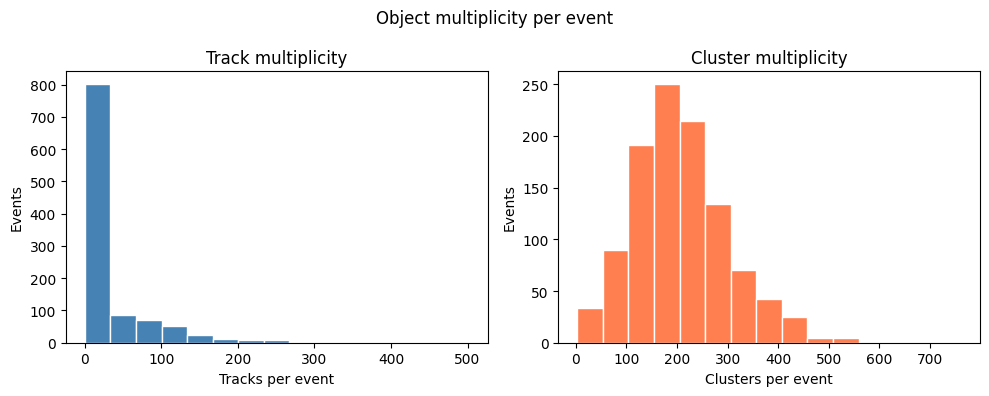

In [14]:
n_trk = [x.shape[0] for x in X_tracks]
n_cl  = [x.shape[0] for x in X_clusters]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(n_trk, bins=15, color="steelblue", edgecolor="white")
axes[0].set(xlabel="Tracks per event", ylabel="Events", title="Track multiplicity")
axes[1].hist(n_cl, bins=15, color="coral", edgecolor="white")
axes[1].set(xlabel="Clusters per event", ylabel="Events", title="Cluster multiplicity")
fig.suptitle("Object multiplicity per event")
plt.tight_layout()
plt.show()

## 2. Track features

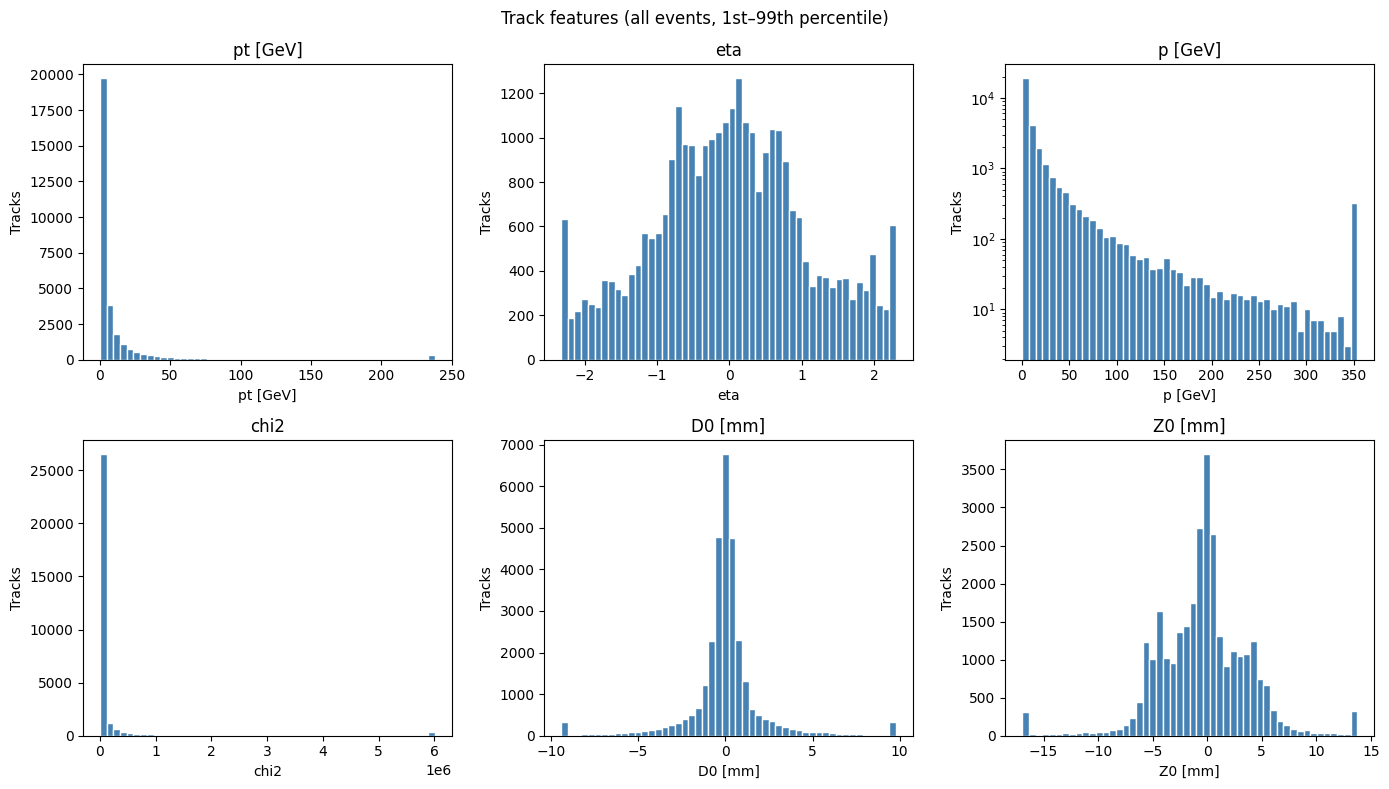

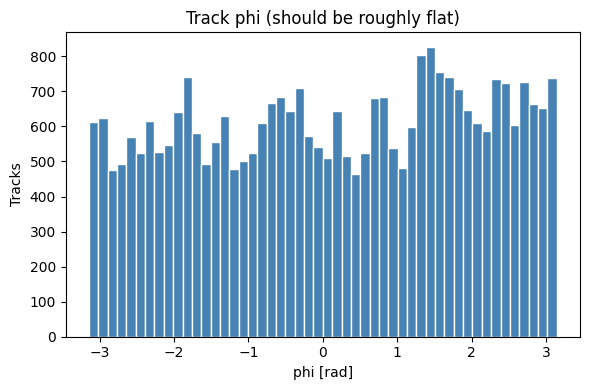

In [15]:
X_trk = np.concatenate(X_tracks, axis=0)
phi_trk = np.arctan2(X_trk[:, TRACK_FEATURES.index("sin_phi")], X_trk[:, TRACK_FEATURES.index("cos_phi")])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (feat, col) in zip(axes, [
    ("pt [GeV]", "pt"), ("eta", "eta"), ("p [GeV]", "p"),
    ("chi2", "chi2"), ("D0 [mm]", "D0"), ("Z0 [mm]", "Z0"),
]):
    vals = X_trk[:, TRACK_FEATURES.index(col)]
    finite = vals[np.isfinite(vals)]
    lo, hi = np.percentile(finite, 1), np.percentile(finite, 99)
    ax.hist(np.clip(finite, lo, hi), bins=50, color="steelblue", edgecolor="white")
    ax.set(xlabel=feat, ylabel="Tracks", title=feat)

axes[2].set_yscale("log")
fig.suptitle("Track features (all events, 1st–99th percentile)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(phi_trk, bins=50, color="steelblue", edgecolor="white")
ax.set(xlabel="phi [rad]", ylabel="Tracks", title="Track phi (should be roughly flat)")
plt.tight_layout()
plt.show()

## 3. Cluster features

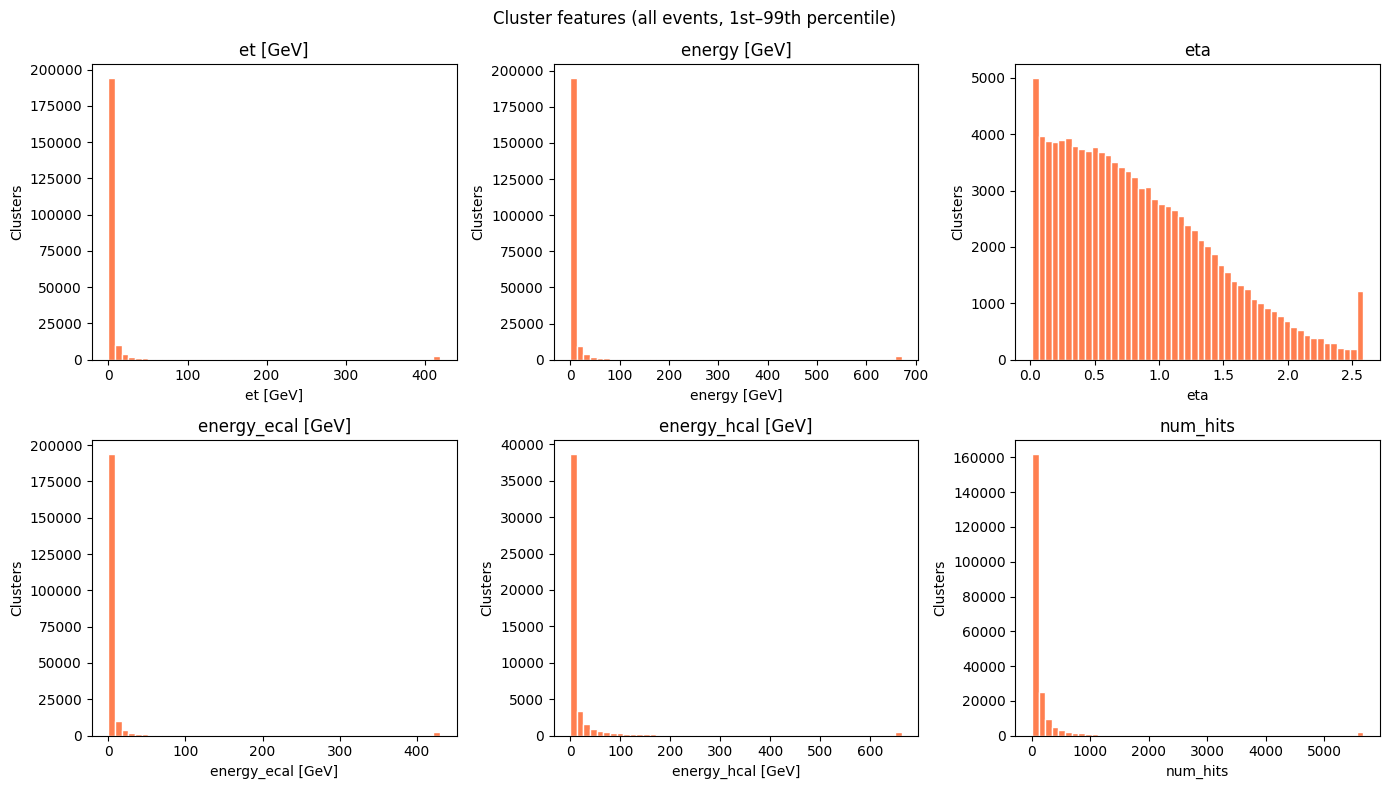

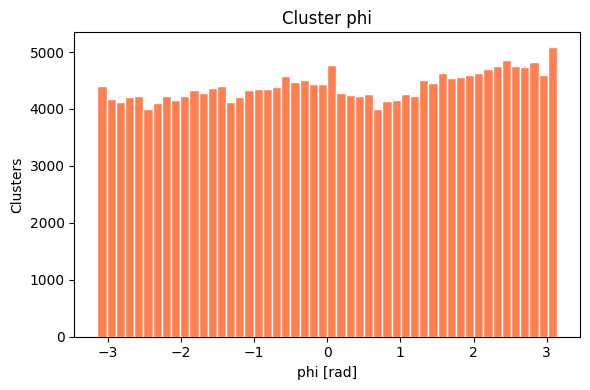

In [16]:
X_cl = np.concatenate(X_clusters, axis=0)
phi_cl = np.arctan2(X_cl[:, CLUSTER_FEATURES.index("sin_phi")], X_cl[:, CLUSTER_FEATURES.index("cos_phi")])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (feat, col) in zip(axes, [
    ("et [GeV]", "et"), ("energy [GeV]", "energy"), ("eta", "eta"),
    ("energy_ecal [GeV]", "energy_ecal"), ("energy_hcal [GeV]", "energy_hcal"), ("num_hits", "num_hits"),
]):
    vals = X_cl[:, CLUSTER_FEATURES.index(col)]
    finite = vals[np.isfinite(vals) & (vals > 0)]
    if len(finite) == 0:
        ax.set_title(f"{feat} (all zero)")
        continue
    lo, hi = np.percentile(finite, 1), np.percentile(finite, 99)
    ax.hist(np.clip(finite, lo, hi), bins=50, color="coral", edgecolor="white")
    ax.set(xlabel=feat, ylabel="Clusters", title=feat)

fig.suptitle("Cluster features (all events, 1st–99th percentile)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(phi_cl, bins=50, color="coral", edgecolor="white")
ax.set(xlabel="phi [rad]", ylabel="Clusters", title="Cluster phi")
plt.tight_layout()
plt.show()

## 4. ECAL vs HCAL energy
Points along the x-axis are EM clusters (photons/electrons). Points along the y-axis are hadronic. Points in the middle are mixed.

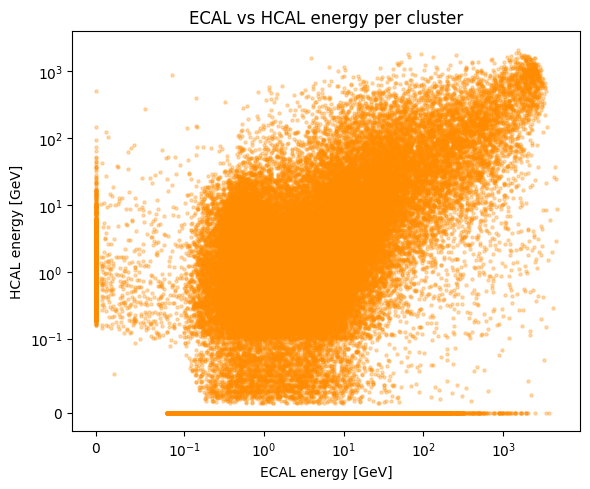

In [17]:
ecal   = X_cl[:, CLUSTER_FEATURES.index("energy_ecal")]
hcal   = X_cl[:, CLUSTER_FEATURES.index("energy_hcal")]
energy = X_cl[:, CLUSTER_FEATURES.index("energy")]
mask   = energy > 0.1

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ecal[mask], hcal[mask], alpha=0.3, s=5, c="darkorange")
ax.set(xlabel="ECAL energy [GeV]", ylabel="HCAL energy [GeV]", title="ECAL vs HCAL energy per cluster")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_yscale("symlog", linthresh=0.1)
plt.tight_layout()
plt.show()

## 5. Particle type composition
PDG=0 means no gen particle was matched to this PF element (background/noise).

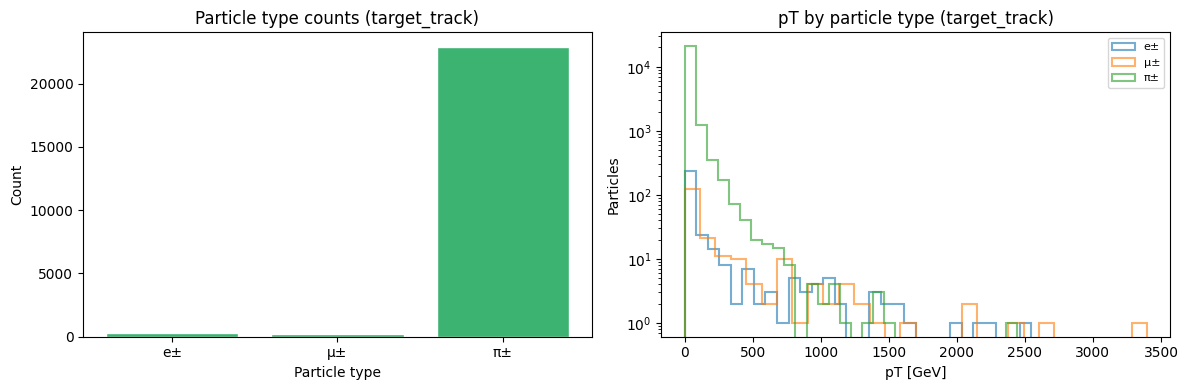

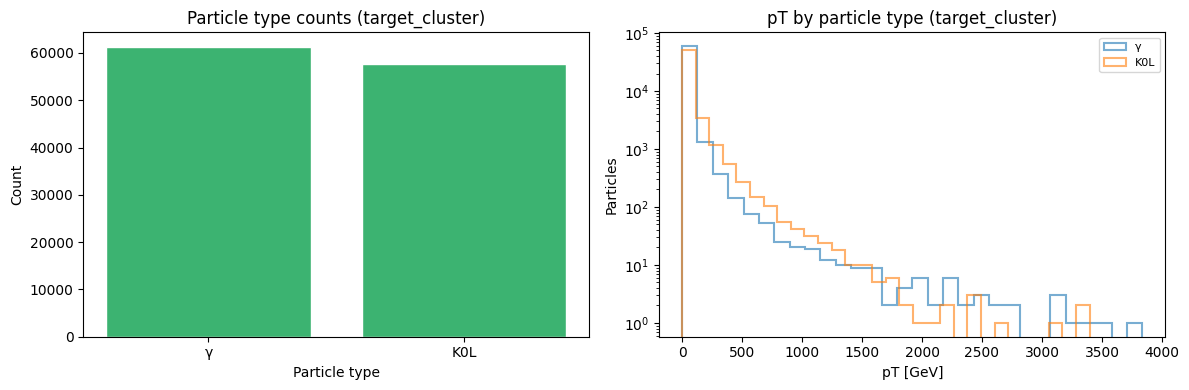

In [18]:
pdg_idx = PARTICLE_FEATURES.index("PDG")
pt_idx  = PARTICLE_FEATURES.index("pt")

for label, yt_list in [("target_track", yt_tracks), ("target_cluster", yt_clusters)]:
    Y = np.concatenate(yt_list, axis=0)
    pdgs = np.abs(Y[:, pdg_idx]).astype(int)
    pts  = Y[:, pt_idx]

    mask = pdgs != 0
    pdgs_assoc = pdgs[mask]
    pts_assoc  = pts[mask]

    unique, counts = np.unique(pdgs_assoc, return_counts=True)
    bar_labels = [PDG_LABELS.get(p, str(p)) for p in unique]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(bar_labels, counts, color="mediumseagreen", edgecolor="white")
    axes[0].set(xlabel="Particle type", ylabel="Count", title=f"Particle type counts ({label})")

    for pdg, lbl in PDG_LABELS.items():
        if pdg == 0:
            continue
        m = pdgs_assoc == pdg
        if m.sum() > 1:
            finite = pts_assoc[m]
            finite = finite[np.isfinite(finite) & (finite > 0)]
            if len(finite) > 1:
                axes[1].hist(finite, bins=30, alpha=0.6, label=lbl, histtype="step", linewidth=1.5)

    axes[1].set(xlabel="pT [GeV]", ylabel="Particles", title=f"pT by particle type ({label})")
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Reco candidate vs target pT
This is the baseline traditional PF is achieving. MLPF should improve the response (closer to 1) and resolution (narrower peak).

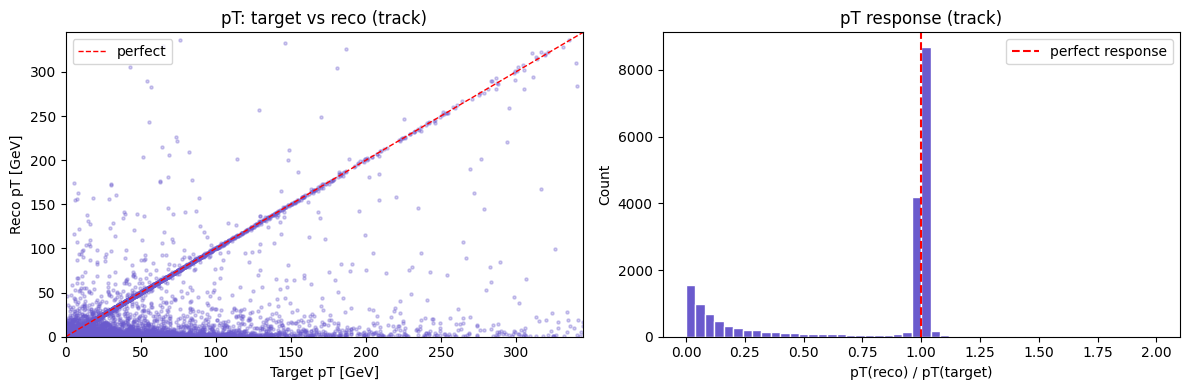

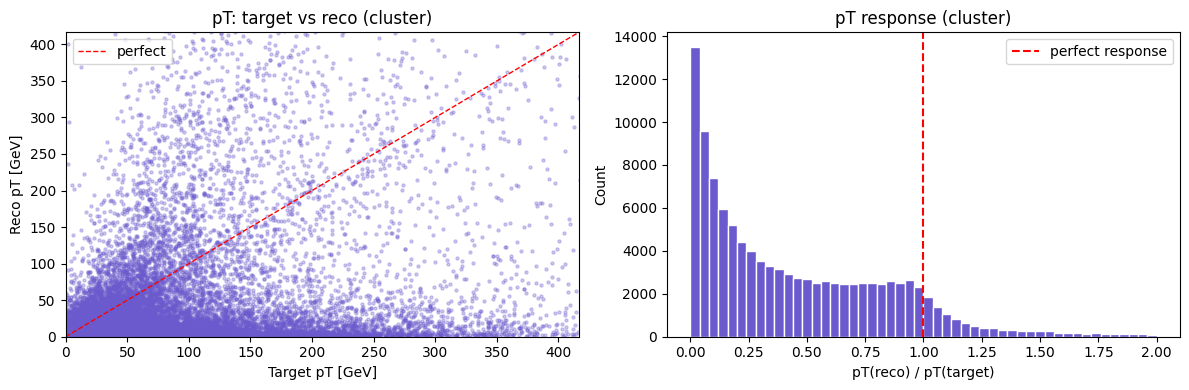

In [19]:
for obj, yt_list, yc_list in [
    ("track",   yt_tracks,   yc_tracks),
    ("cluster", yt_clusters, yc_clusters),
]:
    Yt = np.concatenate(yt_list, axis=0)
    Yc = np.concatenate(yc_list, axis=0)
    mask = np.abs(Yt[:, pdg_idx]) > 0

    pt_t = Yt[mask, pt_idx]
    pt_c = Yc[mask, pt_idx]
    both = (pt_t > 0) & (pt_c > 0) & np.isfinite(pt_t) & np.isfinite(pt_c)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(pt_t[both], pt_c[both], alpha=0.3, s=5, c="slateblue")
    lim = np.percentile(pt_t[both], 99)
    axes[0].plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect")
    axes[0].set(xlabel="Target pT [GeV]", ylabel="Reco pT [GeV]", title=f"pT: target vs reco ({obj})")
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    axes[0].legend()

    ratio = pt_c[both] / pt_t[both]
    axes[1].hist(ratio, bins=50, range=(0, 2), color="slateblue", edgecolor="white")
    axes[1].axvline(1.0, color="red", linestyle="--", label="perfect response")
    axes[1].set(xlabel="pT(reco) / pT(target)", ylabel="Count", title=f"pT response ({obj})")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7. MET and jets

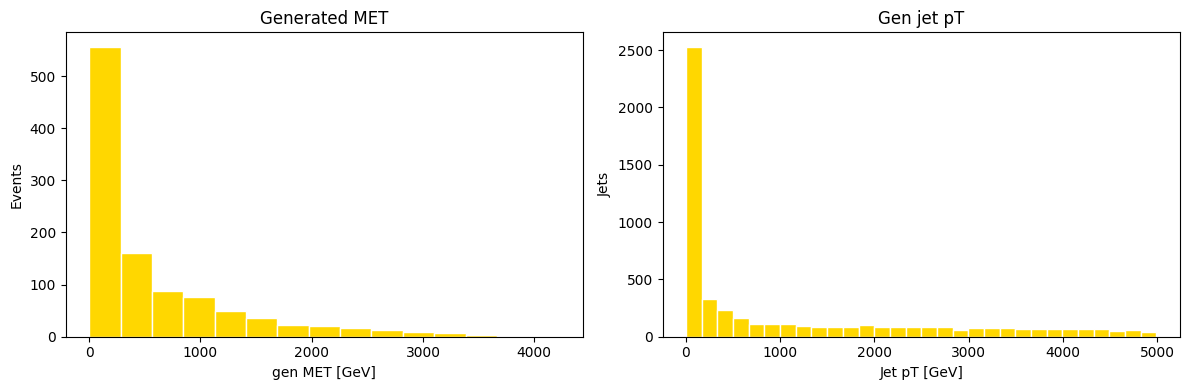

In [20]:
genmets_arr = np.array(genmets)
jet_pts = np.concatenate([j[:, 0] for j in genjets if j.shape[0] > 0])
jet_pts = jet_pts[jet_pts > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(genmets_arr, bins=15, color="gold", edgecolor="white")
axes[0].set(xlabel="gen MET [GeV]", ylabel="Events", title="Generated MET")

axes[1].hist(jet_pts, bins=30, color="gold", edgecolor="white")
axes[1].set(xlabel="Jet pT [GeV]", ylabel="Jets", title="Gen jet pT")
plt.tight_layout()
plt.show()

## 8. Target jets vs gen jets
`genjet` is clustered from all generator-level truth particles (includes neutrinos, no detector acceptance cuts). `targetjet` is clustered from the `ytarget` particles instead, i.e. only the truth particles that were actually matched to a reconstructable track/cluster. Comparing the two shows the effect of detector acceptance and invisible particles (neutrinos) on jet reconstruction.

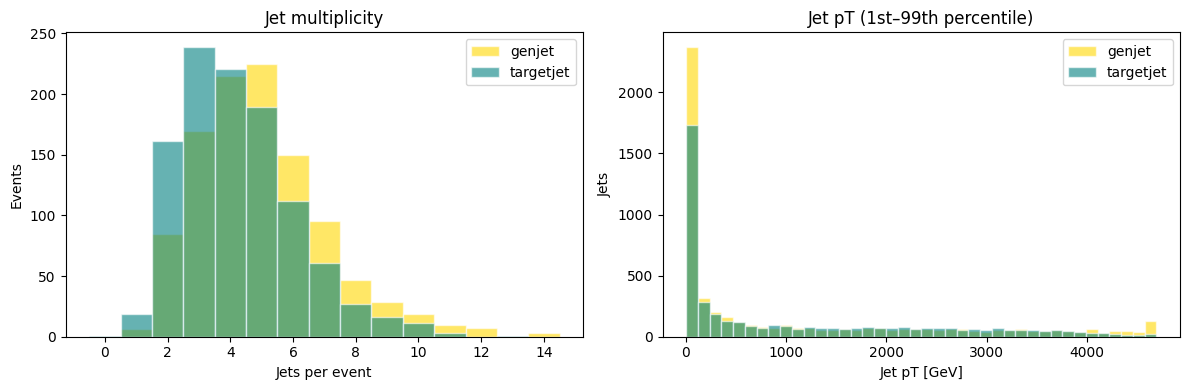

Mean jets/event  -  genjet: 4.99, targetjet: 4.24


In [21]:
n_genjet = np.array([j.shape[0] for j in genjets])
n_targetjet = np.array([j.shape[0] for j in targetjets])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(0, max(n_genjet.max(), n_targetjet.max()) + 2) - 0.5
axes[0].hist(n_genjet, bins=bins, alpha=0.6, label="genjet", color="gold", edgecolor="white")
axes[0].hist(n_targetjet, bins=bins, alpha=0.6, label="targetjet", color="teal", edgecolor="white")
axes[0].set(xlabel="Jets per event", ylabel="Events", title="Jet multiplicity")
axes[0].legend()

genjet_pt = np.concatenate([j[:, 0] for j in genjets if j.shape[0] > 0])
targetjet_pt = np.concatenate([j[:, 0] for j in targetjets if j.shape[0] > 0])
genjet_pt = genjet_pt[genjet_pt > 0]
targetjet_pt = targetjet_pt[targetjet_pt > 0]

lo = min(genjet_pt.min(), targetjet_pt.min())
hi = np.percentile(np.concatenate([genjet_pt, targetjet_pt]), 99)
axes[1].hist(np.clip(genjet_pt, lo, hi), bins=40, alpha=0.6, label="genjet", color="gold", edgecolor="white")
axes[1].hist(np.clip(targetjet_pt, lo, hi), bins=40, alpha=0.6, label="targetjet", color="teal", edgecolor="white")
axes[1].set(xlabel="Jet pT [GeV]", ylabel="Jets", title="Jet pT (1st–99th percentile)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean jets/event  -  genjet: {n_genjet.mean():.2f}, targetjet: {n_targetjet.mean():.2f}")